## TP5: Apprentissage par renforcement tabulaire

Dans ce TP, nous allons mettre en oeuvre les algorithmes:
- de programmation dynamique
- d'apprentissage par renforcement tabulaire

Ces algorithmes sont étudiés pendant le cours 5. Nous allons travailler sur un problème de contrôle relativement simple, qui consiste à contrôler un bras robotique simulé en 2D afin qu'il atteigne une cible donnée.

Ce problème est suffisamment simple pour que:
- On puisse obtenir des résultats satisfaisants en discrétisant l'environnement
- Les algorithmes implémentés convergent rapidement

Le code permettant de simuler cet environnement est donné dans le fichier arm.py. Il ne sera pas nécessaire de le modifier pendant ce TP.

La cellule suivante vous montre comment utiliser la classe Arm du module arm.py pour générer une trajectoire avec le simulateur:

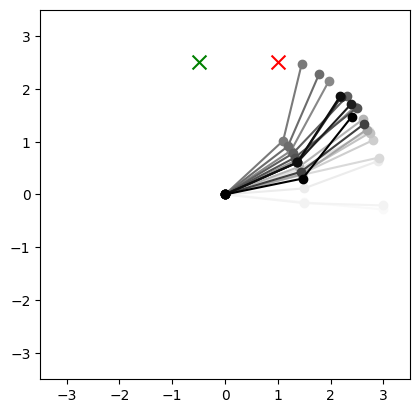

In [1]:
from arm import Arm
from tqdm.notebook import tqdm
import numpy as np
from matplotlib import pyplot as plt

env = Arm(
    lengths=[1.5, 1.5],
    target_position=[-0.5, 2.5],
    obstacle_position=[1., 2.5]
)

# Initialisation de l'environnement
state, joints_xy, reward = env.reset()

# On simule une trajectoire de 20 steps
nbstep = 20

# Pour sauvegarder la trajectoire
traj = np.zeros((nbstep+1, env.n_dofs+1, 2))
traj[0] = joints_xy

for step in range(nbstep):

    # Action aléatoire dans [-1, 1] x [-1, 1]
    action = np.random.uniform(-np.pi/12, np.pi/12, 2)

    # On effectue l'action
    state, joints_xy, reward = env.step(action)

    # Sauvegarde
    traj[step+1] = joints_xy

# Affichage de la trajectoire
env.display_trajectory(traj)

Le problème donné correspond au MDP suivant:
- $\mathcal{S} = [0, \pi]^2$ : l'état correspond à la position angulaire des deux articulations du bras
- $\mathcal{A} = [-\frac{\pi}{12}, \frac{\pi}{12}]^2$ : l'action correspond à la vitesse angulaire instantannée appliquée à chacune des deux articulations
- la récompense correspond à la distance de l'effecteur (le bout du bras) par rapport à l'obstacle (en rouge), à laquelle on soustrait la distance par rapport à la cible (en vert).
- la fonction de transition correspond à l'application de la vitesse angulaire instantannée sur les deux articulations du bras

### 1. Discrétisation de l'environnement

Le RL tabulaire ne fonctionne que lorsque l'espace d'action et l'espace d'état sont discrets, ce qui n'est pour l'instant pas le cas. Pour discrétiser le MDP, nous allons considérer que l'espace d'action est $\{-\frac{\pi}{12}, 0, \frac{\pi}{12}\}^2$. Pour chaque articulation, l'agent à le choix entre tourner dans un sens, dans l'autre, ou de rester immobile. Le nouvel espace d'action est donc de taille $3\times 3 = 9$.
Cette contrainte sur les actions assure également que l'état ne peux prendre qu'un nombre fini de valeur, avec 24 positions angulaires possibles pour chaque articulation. Le nouvel espace d'état est donc de taille $24 \times 24 = 576$. La figure suivante affiche certains états possibles et leurs indices associés:


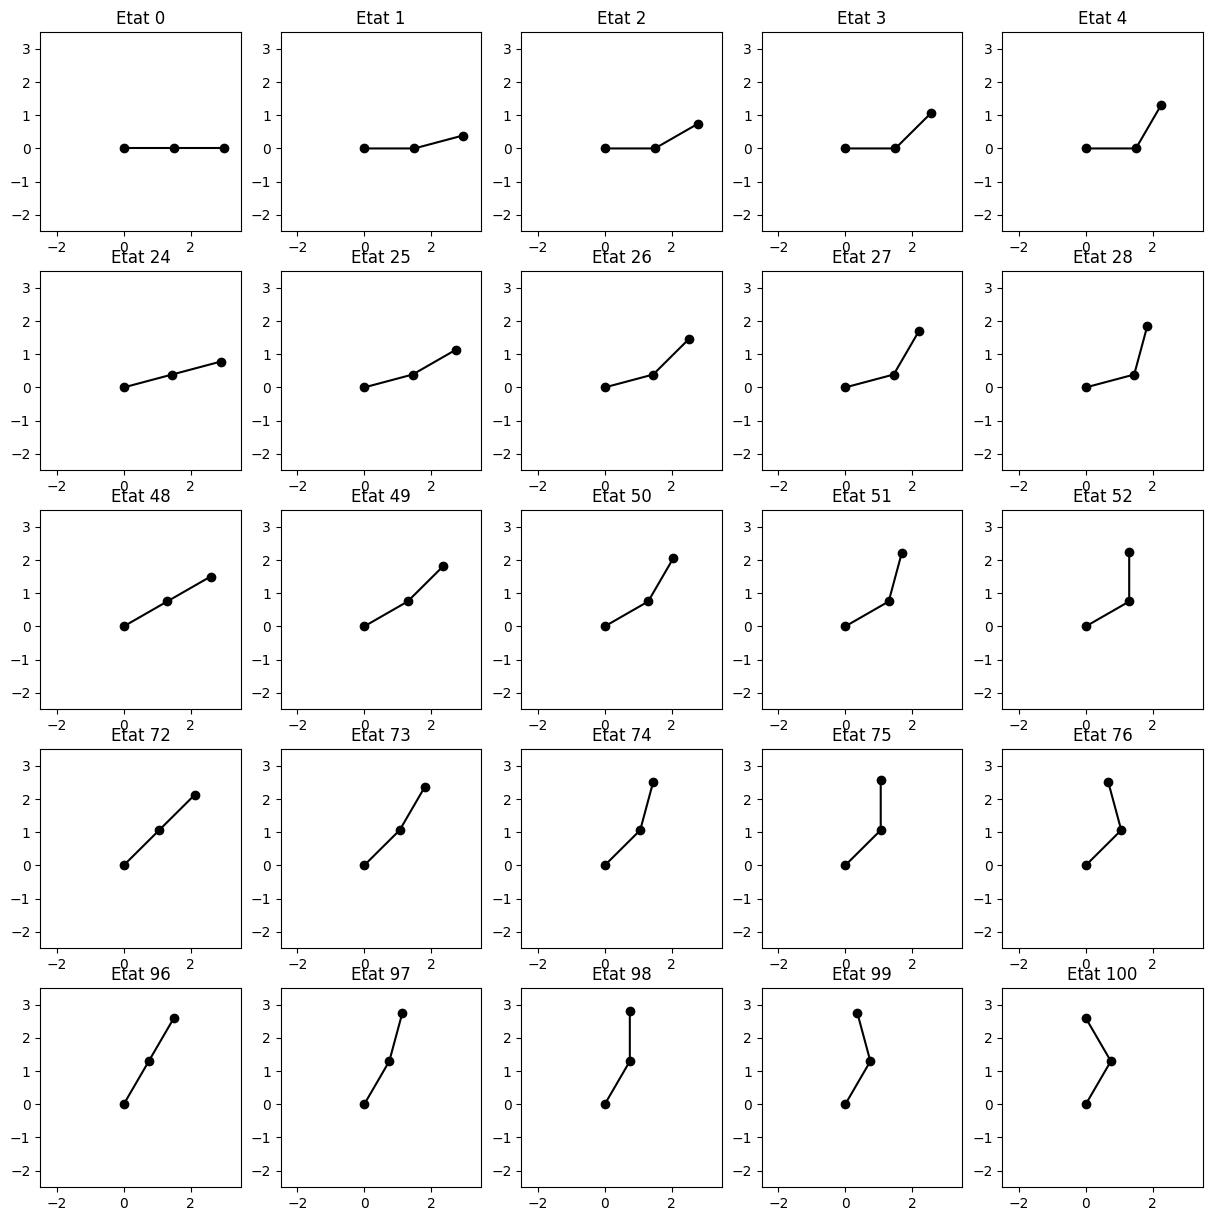

In [2]:
fig, axs = plt.subplots(5, 5, figsize=(15, 15))
for i, j in np.ndindex(5, 5):
    ax = axs[i, j]
    state, joints_xy, reward = env.reset()
    for _ in range(i):
        action = [np.pi/12, 0]
        state, joints_xy, reward = env.step(action)
    for _ in range(j):
        action = [0, np.pi/12]
        state, joints_xy, reward = env.step(action)

    joints_xy = np.array(joints_xy)
    ax.plot(joints_xy[:, 0], joints_xy[:, 1], '-o', c='black')
    ax.set_title(f"Etat {i*24+j}")
    ax.set_xlim(-2.5, 3.5)
    ax.set_ylim(-2.5, 3.5)
plt.show()

On fournit l'implémentation des fonctions `transition` et `reward` du MDP discrétisé. 

La fonction `transition` calcule l'indice du prochain état du MDP en fonction de l'indice de l'état courant et de l'indice de l'action effectuée.

La fonction `reward` calcule la récompense en fonction de l'indice de l'état d'arrivée.

In [3]:
def transition_function(state_id, action_id):
    """
    Fonction de transition

    Parameters
    ----------
    state_id : int
        Identifiant de l'état courant
    action_id : int
        Identifiant de l'action
        0 = [-pi/12, -pi/12]
        1 = [-pi/12, 0]
        2 = [-pi/12, pi/12]
        3 = [0, -pi/12]
        4 = [0, 0]
        5 = [0, pi/12]
        6 = [pi/12, -pi/12]
        7 = [pi/12, 0]
        8 = [pi/12, pi/12]

    Returns
    -------
    int
        Identifiant de l'état suivant
    """
    state_1 = state_id // 24
    action_1 = action_id // 3

    state_2 = state_id % 24
    action_2 = action_id % 3

    next_state_1 = (state_1 + action_1 - 1) % 24
    next_state_2 = (state_2 + action_2 - 1) % 24

    return next_state_1 * 24 + next_state_2


def reward_function(next_state_id):
    """
    Fonction de récompense

    Parameters
    ----------
    next_state_id : int
        Identifiant de l'état suivant

    Returns
    -------
    float
        Récompense
    """
    angle_1 = (next_state_id // 24) * np.pi / 12
    angle_2 = (next_state_id % 24) * np.pi / 12
    end_effector_position = env.fw_kinematics([angle_1, angle_2])[0]
    distance_to_target = np.linalg.norm(
        end_effector_position - np.array(env.target_position))
    distance_to_obstacle = np.linalg.norm(
        end_effector_position - np.array(env.obstacle_position))

    return 0.1 + np.exp(-distance_to_target) \
        - 2 * np.exp(-0.5*distance_to_obstacle)

### 2. Programmation dynamique

Dans cette partie, vous allez implémenter les algorithmes de Value Iteration et Policy Iteration. 

#### 2.1. Value Iteration

L'algorithme de Value Iteration part d'une fonction de valeur initialisée à 0 (par exemple) et applique itérativement l'opérateur de Bellmann optimal jusqu'à convergence vers la fonction de valeur optimale.

Dans un second temps, on déduit une politique optimale de cette fonction de valeur optimale.

##### Question 1: 

Complétez la fonction suivante, permettant d'appliquer l'opérateur de Bellman optimal sur une value function `values`. La fonction devra renvoyer la nouvelle value function, ainsi que la valeur de $\Delta$ résultant de l'application de l'opérateur (cf les slides du cours sur la Value Iteration).

In [4]:
def optimal_bellman_operator(value_function, gamma=0.9):
    
    # Delta max atteint pendant l'itération
    delta_max = 0

    # On parcourt tous les états possibles
    for state_id in range(24*24):

        # A compléter
        ...
        v = value_function[state_id]

        # Liste pour stocker la valeur espérée de chaque action
        action_values = []
        
        # Il y a 9 actions possibles (identifiants de 0 à 8)
        for action_id in range(9):
            # L'environnement est déterministe : on récupère l'unique prochain état
            next_state_id = transition_function(state_id, action_id)
            
            # On récupère la récompense associée
            reward = reward_function(next_state_id)
            
            # r(s, a) + gamma * V(s') (on enlve la proba car on connait déjà l'état d'après donc c'est =1)
            action_value = reward + gamma * value_function[next_state_id]
            action_values.append(action_value)
            
        # On trouve la valeur maximale parmi toutes les actions
        value_function[state_id] = max(action_values)
        
        # Mise à jour du delta maximum
        delta_max = max(delta_max, abs(v - value_function[state_id]))
    
    return value_function, delta_max

##### Question 2:

Complétez la fonction suivante implémentant l'algorithme de Value Iteration. La fonction doit appliquer l'opérateur de Bellman optimal jusqu'à convergence (déterminée par un seuil donné en paramètre), et retourner la fonction de valeur optimale $V^*$.

In [5]:
def value_iteration(seuil=1e-2):

    # On initialise une value function avec des valeurs à 
    optimal_value_function = [0] * 576
    delta_max = float('inf')

    # A compléter
    while delta_max > seuil:
        optimal_value_fonction, delta_max = optimal_bellman_operator(optimal_value_function)
    
    return optimal_value_function

##### Question  3:

Complétez la fonction suivante correspondant à la politique déduite de la fonction de valeur optimale $V^*$ obtenue après convergence de l'algorithme de Value Iteration. Cette fonction prend en entrée la fonction de valeur $V^*$, et le coefficient $\gamma$, et doit retourner la politique greedy $\pi^*$, sous la forme d'une liste de taille 576 contenant l'indice de l'action choisie par la politique greedy dans chacun des 576 états possibles. (Légère erreur dans la slide qui présente l'algorithme dans le cours, il manque le coefficient $\gamma$ à la dernière ligne.)

In [6]:
def greedy_policy(value_function, gamma=0.9):
    # Doit contenir l'id de l'action optimale pour chaque état
    policy = [0] * 576

    # A compléter
    for state_id in range(576):
        best_action = 0
        action_values = []
        
        # Il y a 9 actions possibles (identifiants de 0 à 8)
        for action_id in range(9):
            # L'environnement est déterministe : on récupère l'unique prochain état
            next_state_id = transition_function(state_id, action_id)
            
            # On récupère la récompense associée
            reward = reward_function(next_state_id)
            
            # r(s, a) + gamma * V(s') (on enlve la proba car on connait déjà l'état d'après donc c'est =1)
            action_value = reward + gamma * value_function[next_state_id]

            action_values.append(action_value)
            
        best_action = np.argmax(action_values)
        policy[state_id] = best_action

    return policy

##### Résultats:

On peut maintenant lancer l'algorithme et tester la politique obtenue. Si votre implémentation fonctionne, la cellule suivant devrait s'exécuter et afficher la trajectoire obtenue avec la politique optimale, ainsi que la somme des récompenses obtenues lors de cette trajectoire.

In [7]:
# Calcul de la fonction de valeur optimale
optimal_value_function = value_iteration()

# Calcul de la politique optimale
optimal_policy = greedy_policy(optimal_value_function)

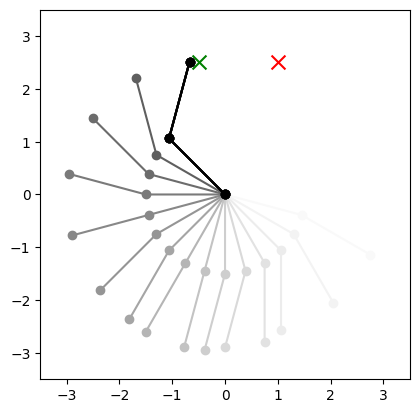

Somme des récompenses sur la trajectoire: -0.34157490960989867


In [8]:
# Initialisation de l'environnement
state, joints_xy, reward = env.reset()

# On simule une trajectoire de 20 steps avec cette politique et cet environnement
nbstep = 20

# Pour sauvegarder la trajectoire
traj = np.zeros((nbstep+1, env.n_dofs+1, 2))
traj[0] = joints_xy

total_reward = 0

for step in range(nbstep):

    # Calcul de l'état discret à partir de l'état continu
    state_1 = int(np.round(state[0] * 12 / np.pi) % 24)
    state_2 = int(np.round(state[1] * 12 / np.pi) % 24)
    state_id = state_1 * 24 + state_2

    # Utilisation de la politique optimale pour déterminer l'action discrète
    action_id = optimal_policy[state_id]

    # Calcul de l'action continue à partir de l'action discrète
    action = [(action_id // 3 - 1) * np.pi / 12,
              (action_id % 3 - 1) * np.pi / 12]

    # Application de l'action
    state, joints_xy, reward = env.step(action)
    total_reward += reward

    # Sauvegarde
    traj[step+1] = joints_xy

# Affichage de la trajectoire
env.display_trajectory(traj)
print(f"Somme des récompenses sur la trajectoire: {total_reward}")

##### Question facultative:

Vous pouvez essayer de tester avec plusieurs valeurs du seuil de convergence. Que se passe-t'il quand le seuil est trop grand ? Que se passe-t'il quand le seuil est trop petit ?

#### 2.2. Policy Iteration

L'algorithme de Policy Iteration définit une politique aléatoire, puis alterne entre deux procédures:
- **Policy Evaluation**: calcule la fonction de valeur $V^\pi$ associée à la politique courante, par convergence en appliquant itérativement l'opérateur de Bellman $T^\pi$
- **Policy Improvement**: met à jour la politique $\pi$ de manière greedy avec la fonction de valeur $V^\pi$

##### Question 4:

Complétez la fonction suivante appliquant l'opérateur de Bellman $T^\pi$ à une fonction de valeur $V_n^\pi$ définie comme la liste des valeurs correspondant aux 576 états possibles. La fonction prend en argument l'estimation courante de la fonction $V_n^\pi$ et la politique $\pi$ définie comme la liste de taille 576 contenant l'indice de l'action correspondant à chacun des 576 états. La fonction doit retourner la nouvelle fonction de valeur $V_{n+1}^\pi$ résultant de l'application de l'opérateur de Bellman.

In [14]:
def bellman_operator(value_function, policy, gamma=0.9):

    # Nouvelle fonction de valeurs
    new_value_function = [0] * 576
    
    # Delta max atteint pendant l'itération
    delta_max = 0

    # On parcourt tous les états possibles
    for state_id in range(24*24):

        # L'action est donnée par la politique que l'on souhaite évaluer
        action_id = policy[state_id]
        
        # L'environnement est déterministe : on récupère l'unique prochain état
        next_state_id = transition_function(state_id, action_id)
        
        # On récupère la récompense associée
        reward = reward_function(next_state_id)
        
        # Application de l'équation de Bellman pour la politique (sans max)
        new_v = reward + gamma * value_function[next_state_id]
        new_value_function[state_id] = new_v
        
        # Mise à jour du delta maximum
        delta_max = max(delta_max, abs(new_v - value_function[state_id]))
    
    return new_value_function, delta_max

##### Question 5:

Complétez la fonction suivante réalisant l'étape de *Policy Evaluation* en appliquant itérativement l'opérateur de Bellman $T^\pi$ jusqu'à convergence, déterminée par un seuil donné. Cette fonction prend en argument la politique à évaluer (toujours représentée par une liste) et une estimation initiale de la fonction de valeur(représentée également par une liste). Elle retourne la fonction de valeur obtenue après convergence.

In [15]:
def policy_evaluation(policy, initial_value_function, seuil=1e-1):

    # On initialise une value function avec des valeurs à 
    value_function = initial_value_function
    delta_max = float('inf')

    # A compléter
    while delta_max > seuil:
        value_function, delta_max = bellman_operator(value_function, policy)
        
    return value_function

##### Question 6:

Complétez la fonction suivante implémentant l'algorithme complet de *Policy Iteration*. La fonction devra retourner la politique obtenue ainsi que la fonction de valeur correspondante.

Pour l'étape de *Policy Improvement*, nous pouvons réutiliser la fonction `greedy_policy` définie précédemment.

L'algorithme doit s'arrêter lorsque la politique reste inchangée par l'étape de *Policy Improvement*.

In [16]:
def policy_iteration(seuil=1e-1):
    # On initialise une politique aléatoire et une value function nulle
    policy = list(np.random.randint(0, 9, 576))
    value_function = [0] * 576

    # True quand la politique n'a pas été modifée par l'iteration
    policy_stable = False

    while not policy_stable:
        # Évaluation de la politique (Policy Evaluation)
        value_function = policy_evaluation(policy, value_function, seuil)
        
        # Amélioration de la politique (Policy Improvement)
        new_policy = greedy_policy(value_function)
        
        # Vérification de la stabilité si la politique a changé
        if new_policy == policy:
            policy_stable = True
        else:
            policy = new_policy

    return policy, value_function

##### Résultats:

On peut maintenant lancer l'algorithme et tester la politique obtenue. Si votre implémentation fonctionne, la cellule suivant devrait s'exécuter et afficher la trajectoire obtenue avec la politique optimale, ainsi que la somme des récompenses obtenues lors de cette trajectoire.

In [17]:
# Calcul de la politique optimale avec Policy Iteration
policy, value_function = policy_iteration()

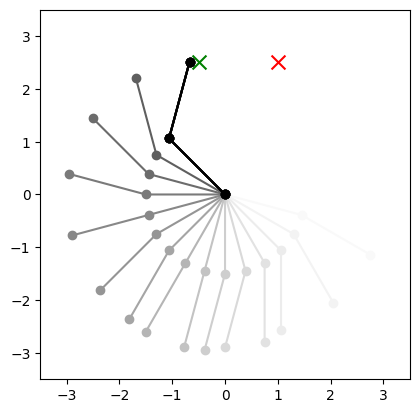

Somme des récompenses sur la trajectoire: -0.34157490960989867


In [18]:
# Initialisation de l'environnement
state, joints_xy, reward = env.reset()

# On simule une trajectoire de 20 steps avec cette politique et cet environnement
nbstep = 20

# Pour sauvegarder la trajectoire
traj = np.zeros((nbstep+1, env.n_dofs+1, 2))
traj[0] = joints_xy

total_reward = 0

for step in range(nbstep):

    # Calcul de l'état discret à partir de l'état continu
    state_1 = int(np.round(state[0] * 12 / np.pi) % 24)
    state_2 = int(np.round(state[1] * 12 / np.pi) % 24)
    state_id = state_1 * 24 + state_2

    # Utilisation de la politique optimale pour déterminer l'action discrète
    action_id = optimal_policy[state_id]

    # Calcul de l'action continue à partir de l'action discrète
    action = [(action_id // 3 - 1) * np.pi / 12,
              (action_id % 3 - 1) * np.pi / 12]

    # Application de l'action
    state, joints_xy, reward = env.step(action)
    total_reward += reward

    # Sauvegarde
    traj[step+1] = joints_xy

# Affichage de la trajectoire
env.display_trajectory(traj)
print(f"Somme des récompenses sur la trajectoire: {total_reward}")

### 3. Q-learning et SARSA

Les algorithmes précédents permettent de trouver la politique optimale grâce à une connaissance a priori des fonctions de transition et récompense. Dans beaucoup de problèmes réels, ces deux éléments seront inconnus. Par exemple en robotique, bien qu'un modèle du robot soit souvent disponible, il ne suffit pas à prédire les effets des actions du robot sur l'environnement.

Les algorithmes d'apprentissage par renforcement, comme Q-learning et SARSA, ont pour but de rechercher la politique optimale du MDP sans avoir de connaissances a priori sur la fonction de transition et la fonction de récompense.

Dans ces deux algorithmes, nous allons utiliser une politique $\epsilon$-greedy, qui assure que l'agent explore son environnement et ne reste pas bloqué à suivre une politique sous-optimale.

##### Question 7: 

Complétez la fonction suivante servant à implémenter la politique $\epsilon$-greedy. Cette fonction prend en argument une *action value function* (définie comme un numpy array de *Q-values*), l'indice de l'état courant pour lequel il faut déterminer l'action, ainsi que le coefficient $\epsilon$.

In [21]:
def epsilon_greedy(q_values, state_id, epsilon):
    if np.random.rand() < epsilon:
        # Exploration : on choisit une action au hasard parmi les 9 possibles (de 0 à 8)
        return np.random.randint(0, 9)
    else:
        # Exploitation : on choisit l'action qui a la plus grande valeur Q pour cet état
        return np.argmax(q_values[state_id])

#### 3.1. Q-learning

##### Question 8:

Complétez et exécutez la cellule suivante implémentant l'algorithme de Q-learning.

Dans cette version de Q-learning, on initialise les Q-values à une valeur volontairement élevée. De cette manière, la politique va avoir tendance à choisir les actions pour lesquelles aucune donnée n'a été collectée. Cette technique permet d'encourager l'exploration de chaque paire d'état-action pendant l'apprentissage.

In [22]:
q_values = np.zeros((576, 9)) + 1

episodes = int(1e4)

epsilon = 0.1
alpha = 0.3
gamma = 0.9 # Ajout du gamma

total_rewards = []

for i in tqdm(range(episodes)):

    # Initialisation de l'environnement
    state, _, _ = env.reset()
    total_reward = 0

    # Calcul de l'état discret à partir de l'état continu
    state_1 = int(np.round(state[0] * 12 / np.pi) % 24)
    state_2 = int(np.round(state[1] * 12 / np.pi) % 24)
    state_id = state_1 * 24 + state_2
    done = False

    for _ in range(nbstep):

        # Choix de l'action avec la politique epsilon greedy
        # A compléter
        action_id = epsilon_greedy(q_values, state_id, epsilon)

        # Calcul de l'action continue à partir de l'action discrète
        action = [(action_id // 3 - 1) * np.pi / 12,
                  (action_id % 3 - 1) * np.pi / 12]

        # Application de l'action
        next_state, _, reward = env.step(action)
        total_reward += reward

        # Calcul de l'état suivant discret à partir de l'état suivant continu
        next_state_1 = int(np.round(state[0] * 12 / np.pi) % 24)
        next_state_2 = int(np.round(state[1] * 12 / np.pi) % 24)
        next_state_id = next_state_1 * 24 + next_state_2

        # Mise à jour de la valeur Q (Equation du Q-learning)
        best_next_q = np.max(q_values[next_state_id])
        td_target = reward + gamma * best_next_q
        td_error = td_target - q_values[state_id, action_id]
        
        q_values[state_id, action_id] += alpha * td_error
        
        # s <- s'
        state_id = next_state_id

    # Sauvegarde de la récompense totale
    total_rewards.append(total_reward)

  0%|          | 0/10000 [00:00<?, ?it/s]

La cellule suivante permet d'afficher l'évolution de la récompense au cours de l'apprentissage.

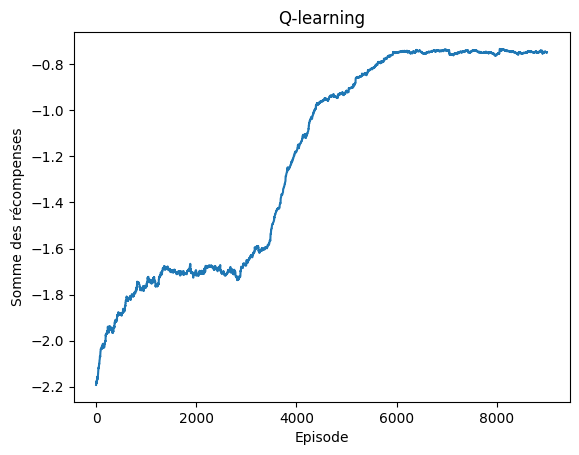

In [23]:
moving_average_rewards = np.convolve(
    total_rewards, np.ones(1000)/1000, mode='valid')
plt.plot(moving_average_rewards)
plt.ylabel('Somme des récompenses')
plt.xlabel('Episode')
plt.title('Q-learning')
plt.show()

##### Question 9:

Afin d'analyser la convergence de l'algorithme de Q-learning, nous pouvons nous appuyez sur la fonction de valeur optimale calculée au début du TP grâce aux méthodes de programmation dynamique.

Si Q-learning converge parfaitement, le tableau de Q-value obtenu doit vérifier l'égalité suivante:

$V^*(s) = \max_a Q(s, a)$

La cellule suivante représente un nuage de 576 points dont l'abscisse est $V(s)$ et l'ordonnée est $\max_a Q(s, a)$.

Répondez aux questions suivantes:
- Qu'observez vous sur cette figure ?
- Est-ce que l'algorithme a complètement convergé ?
- Est-ce que la convergence est meilleure sur les états de valeur basse ou haute ? Pourquoi ?

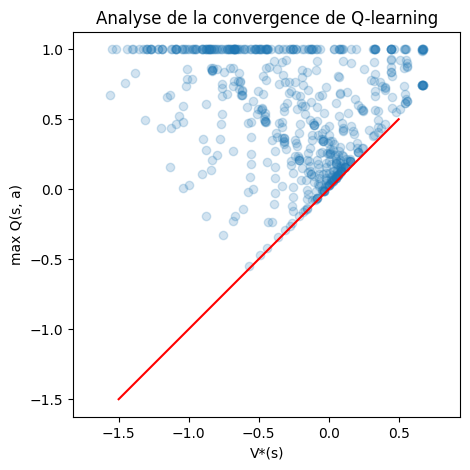

In [24]:
plt.figure(figsize=(5, 5))
plt.plot(optimal_value_function, np.max(q_values, axis=1), 'o', alpha=0.2)
plt.plot([-1.5, 0.5], [-1.5, 0.5], 'r')
plt.xlabel('V*(s)')
plt.ylabel('max Q(s, a)')
plt.axis('equal')
plt.title('Analyse de la convergence de Q-learning')
plt.show()

##### Question 10:

Lancez la cellule suivante permettant de tester la politique obtenue avec Q-learning. On l'obtient en utilisant la politique $\epsilon$-greedy avec $\epsilon=0$.

- La trajectoire est-elle optimale ou presque optimale ? (on peut pour cela la comparer à la trajectoire obtenue avec les méthodes de programmation dynamique)
- Essayez de relancer l'algorithme de Q-learning avec les Q-values initialisées à 0 et comparer les résultats ? Concluez sur l'importance de l'exploration en RL.

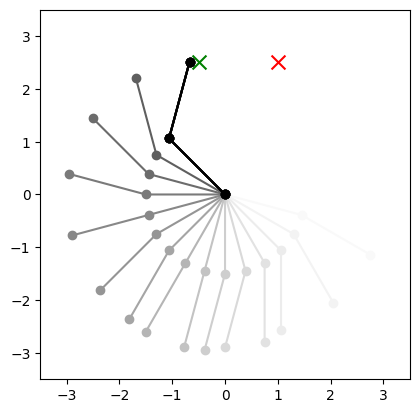

Somme des récompenses sur la trajectoire: -0.34157490960989867


In [25]:
# Initialisation de l'environnement
state, joints_xy, reward = env.reset()

# On simule une trajectoire de 20 steps avec cette politique et cet environnement
nbstep = 20

# Pour sauvegarder la trajectoire
traj = np.zeros((nbstep+1, env.n_dofs+1, 2))
traj[0] = joints_xy

total_reward = 0

for step in range(nbstep):

    # Calcul de l'état discret à partir de l'état continu
    state_1 = int(np.round(state[0] * 12 / np.pi) % 24)
    state_2 = int(np.round(state[1] * 12 / np.pi) % 24)
    state_id = state_1 * 24 + state_2

    # Utilisation de la politique optimale pour déterminer l'action discrète
    action_id = epsilon_greedy(q_values, state_id, epsilon=0.0)

    # Calcul de l'action continue à partir de l'action discrète
    action = [(action_id // 3 - 1) * np.pi / 12,
              (action_id % 3 - 1) * np.pi / 12]

    # Application de l'action
    state, joints_xy, reward = env.step(action)
    total_reward += reward

    # Sauvegarde
    traj[step+1] = joints_xy

# Affichage de la trajectoire
env.display_trajectory(traj)
print(f"Somme des récompenses sur la trajectoire: {total_reward}")

#### 3.2. SARSA

##### Question 11:

Dans la cellule suivante, recopiez et adaptez l'algorithme de Q-learning pour obtenir l'algorithme SARSA.

SARSA est la version *on-policy* de Q-learning. Cela veut dire que SARSA apprend une estimation des Q-values correspondant à la politique d'exploration ($\epsilon$-greedy) et non pas celles correspondant à la politique *greedy*. Lancez l'algorithme et comparez les politiques obtenues. Essayer d'intérpréter la politique obtenue avec SARSA.

In [26]:
q_values = np.zeros((576, 9)) + 1

episodes = int(1e4)

epsilon = 0.1
alpha = 0.3
gamma = 0.9 # Ajout du gamma

total_rewards = []

for i in tqdm(range(episodes)):

    # Initialisation de l'environnement
    state, _, _ = env.reset()
    total_reward = 0

    # Choix de l'action avec la politique epsilon greedy
    # A compléter
    action_id = epsilon_greedy(q_values, state_id, epsilon)

    # Calcul de l'état discret à partir de l'état continu
    state_1 = int(np.round(state[0] * 12 / np.pi) % 24)
    state_2 = int(np.round(state[1] * 12 / np.pi) % 24)
    state_id = state_1 * 24 + state_2
    done = False

    for _ in range(20):

        # Calcul de l'action continue à partir de l'action discrète
        action = [(action_id // 3 - 1) * np.pi / 12,
                  (action_id % 3 - 1) * np.pi / 12]

        # Application de l'action
        next_state, _, reward = env.step(action)
        total_reward += reward

        # Calcul de l'état suivant discret à partir de l'état suivant continu
        next_state_1 = int(np.round(state[0] * 12 / np.pi) % 24)
        next_state_2 = int(np.round(state[1] * 12 / np.pi) % 24)
        next_state_id = next_state_1 * 24 + next_state_2

        # Choix de l'action suivante avec la politique epsilon greedy
        next_action_id = epsilon_greedy(q_values, next_state_id, epsilon)

        # Mise à jour de la valeur Q (Formule SARSA au lieu de max)
        td_target = reward + gamma * q_values[next_state_id, next_action_id]
        td_error = td_target - q_values[state_id, action_id]
        
        q_values[state_id, action_id] += alpha * td_error

        # s <- s', a <- a'
        state_id = next_state_id
        action_id = next_action_id

    # Sauvegarde de la récompense totale
    total_rewards.append(total_reward)

  0%|          | 0/10000 [00:00<?, ?it/s]

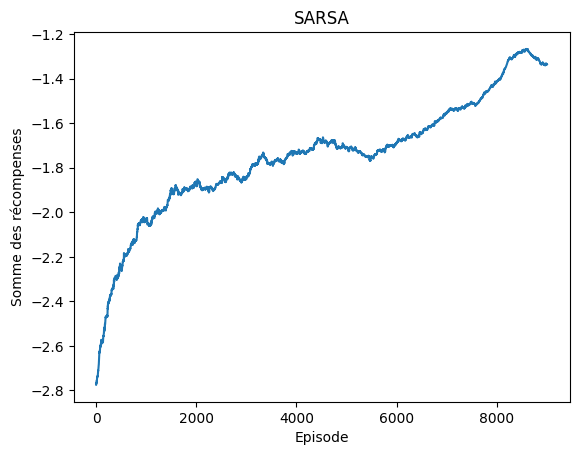

In [27]:
moving_average_rewards = np.convolve(
    total_rewards, np.ones(1000)/1000, mode='valid')
plt.plot(moving_average_rewards)
plt.ylabel('Somme des récompenses')
plt.xlabel('Episode')
plt.title('SARSA')
plt.show()

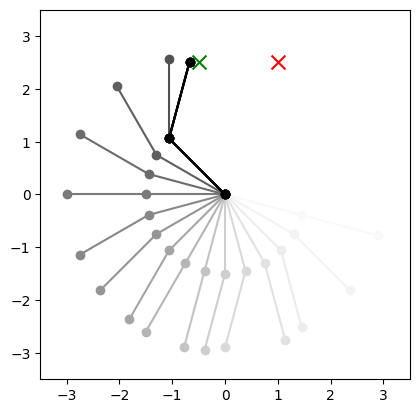

Somme des récompenses sur la trajectoire: -0.48515799630826983


In [28]:
# Initialisation de l'environnement
state, joints_xy, reward = env.reset()

# On simule une trajectoire de 20 steps avec cette politique et cet environnement
nbstep = 20

# Pour sauvegarder la trajectoire
traj = np.zeros((nbstep+1, env.n_dofs+1, 2))
traj[0] = joints_xy

total_reward = 0

for step in range(nbstep):

    # Calcul de l'état discret à partir de l'état continu
    state_1 = int(np.round(state[0] * 12 / np.pi) % 24)
    state_2 = int(np.round(state[1] * 12 / np.pi) % 24)
    state_id = state_1 * 24 + state_2

    # Utilisation de la politique optimale pour déterminer l'action discrète
    action_id = epsilon_greedy(q_values, state_id, epsilon=0.0)

    # Calcul de l'action continue à partir de l'action discrète
    action = [(action_id // 3 - 1) * np.pi / 12,
              (action_id % 3 - 1) * np.pi / 12]

    # Application de l'action
    state, joints_xy, reward = env.step(action)
    total_reward += reward

    # Sauvegarde
    traj[step+1] = joints_xy

# Affichage de la trajectoire
env.display_trajectory(traj)
print(f"Somme des récompenses sur la trajectoire: {total_reward}")

##### Question 12:

Quelles sont les limites des méthodes étudiées dans ce TP ?

- De la discrétisation ?
- Des méthodes de programmation dynamique ?
- Des algorithmes Q-learning et SARSA ?